## Imports and Model Definition

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# THEORETICAL MODEL
# ==========================================

n = 4  # Fixed number of subunits 

def viscoelastic_conductance(t, g_inf, tau):
    """
    Calculates Potassium conductance based on the Kelvin-Voigt model.
    
    Equation derived from Manuscript Eq. 6:
    g(t) = g_inf * (1 - exp(-t / tau))^n
    
    Where:
    - n = 4 (number of subunits)
    - tau = eta* / E* (mechanical time constant) 
    - g_inf = Vm / E* (steady state conductance) 
    """
    
    return g_inf * (1 - np.exp(-t / tau))**n

def calculate_mechanical_properties(V_m, g_inf, tau):
    """
    Derives mechanical properties E* and eta* from fitted parameters.
    
    Based on Manuscript Eq. 7 and Eq. 8:
    - E* (Elasticity/c) = V_m / g_inf^(1/n) 
    - eta* (Viscosity/c) = E* * tau 
    """
    # Avoid division by zero if conductance is 0
    if g_inf == 0:
        return 0, 0
    
    # E* = Vm / g_infty (Linear relationship expected) 
    E_star = abs(V_m) / np.power(g_inf, 1/n) 
    
    # eta* = E* * tau 
    eta_star = E_star * tau
    
    return E_star, eta_star

Data from a paper tutorial on ABC parameter estimation for the Hodgkin-Huxley action potential model.

* Daly, A. C., Gavaghan, D. J., Holmes, C., & Cooper, J. (2015).  Royal Society Open Science, 2(12). https://doi.org/10.1098/rsos.150499

Data digitized from the original 1952 Hodgkin-Huxley publication: [http://plotdigitizer.sourceforge.net] 

* HODGKIN AL, HUXLEY AF. A quantitative description of membrane current and its application to conduction and excitation in nerve. J Physiol. 1952 Aug;117(4):500-44. doi: 10.1113/jphysiol.1952.sp004764. PMID: 12991237; PMCID: PMC1392413.

In [24]:
import hhdata

In [46]:
results = {
    "V_m": [],
    "E_star": [],
    "eta_star": [],
    "fits": {}
}

for ih in  np.arange(0, 10, 1):
    dat = hhdata.fig3(ih+1)
    t_data = np.array(dat[0])
    g_data = np.array(dat[1])
    g0 = g_data[0]
    V_m = dat[4]
    
    # Initial guess for optimizer [g_inf, tau]
    p0 = [np.max(g_data), 2.0]
    
    try:
        # Fit the mechanical model to the data 
        print("Starting curve fitting...")
        popt, pcov = curve_fit(viscoelastic_conductance, t_data, g_data, p0=p0)
        g_inf_est, tau_est = popt
        
        # Calculate Mechanical Properties E* and eta*
        E_star, eta_star = calculate_mechanical_properties(V_m, g_inf_est, tau_est)
        
        # Store results
        results["V_m"].append(V_m)
        results["E_star"].append(E_star)
        results["eta_star"].append(eta_star)
        t_fit = np.linspace(t_data[0], t_data[-1], 200)
        results["fits"][V_m] = (t_data, g_data, t_fit, viscoelastic_conductance(t_fit, *popt))
        
        print(f"Voltage {V_m} mV: E* = {E_star:.2f}, eta* = {eta_star:.2f}")
        
    except RuntimeError:
        print(f"Fit failed for voltage {V_m}")
        
# Convert lists to numpy arrays for plotting
results["V_m"] = np.array(results["V_m"])
results["E_star"] = np.array(results["E_star"])
results["eta_star"] = np.array(results["eta_star"])

Starting curve fitting...
Voltage -100 mV: E* = 47.26, eta* = 38.58
Starting curve fitting...
Voltage -88 mV: E* = 42.64, eta* = 39.05
Starting curve fitting...
Voltage -76 mV: E* = 37.67, eta* = 40.13
Starting curve fitting...
Voltage -63 mV: E* = 31.84, eta* = 39.36
Starting curve fitting...
Voltage -51 mV: E* = 26.95, eta* = 39.30
Starting curve fitting...
Voltage -38 mV: E* = 21.39, eta* = 39.71
Starting curve fitting...
Voltage -32 mV: E* = 18.63, eta* = 41.33
Starting curve fitting...
Voltage -26 mV: E* = 16.02, eta* = 38.84
Starting curve fitting...
Voltage -19 mV: E* = 12.95, eta* = 35.55
Starting curve fitting...
Voltage -10 mV: E* = 9.27, eta* = 19.60


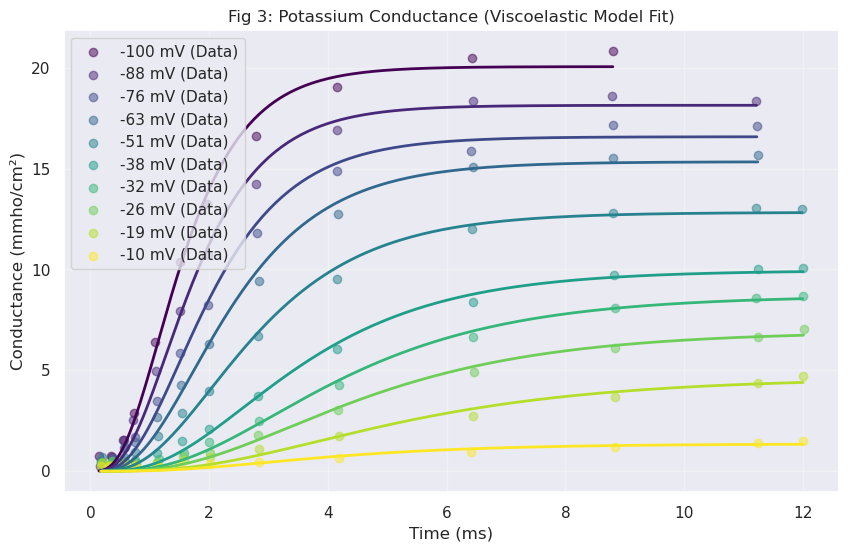

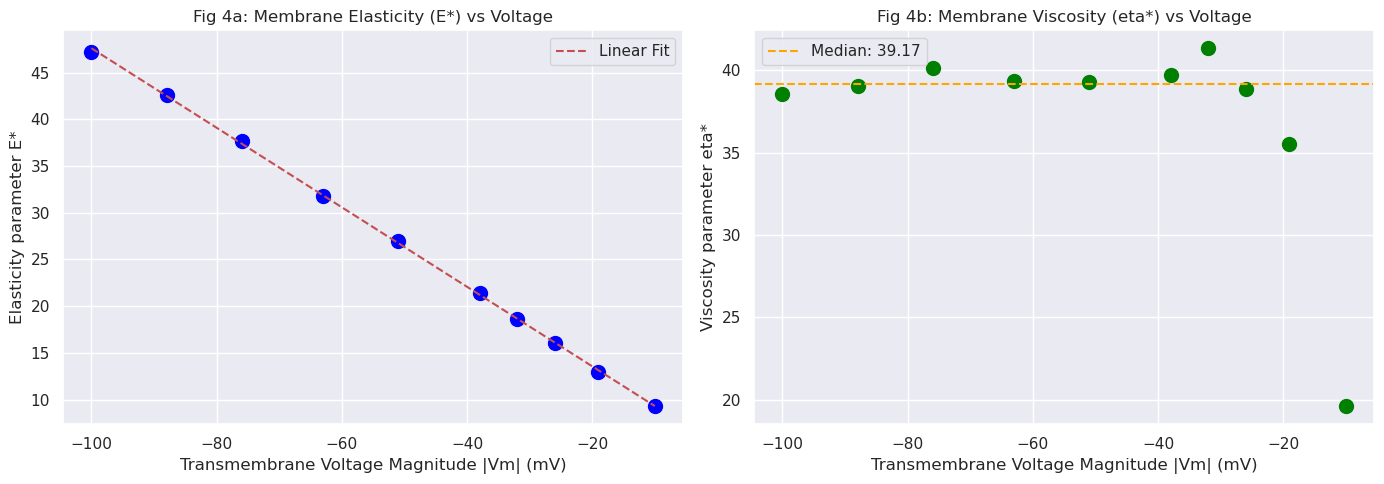

In [47]:
# ==========================================
# VISUALIZATION
# ==========================================

# 1. Recreating Figure 3: Potassium Conductance Fits
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results["fits"])))

for idx, (V_m, (t, g_exp, t_fit, g_fit)) in enumerate(results["fits"].items()):
    # Plot experimental data (circles)
    plt.scatter(t, g_exp, color=colors[idx], alpha=0.5, label=f'{V_m} mV (Data)')
    # Plot model fit (solid line)
    plt.plot(t_fit, g_fit, color=colors[idx], linestyle='-', linewidth=2)

plt.title("Fig 3: Potassium Conductance (Viscoelastic Model Fit)")
plt.xlabel("Time (ms)")
plt.ylabel("Conductance (mmho/cm²)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Recreating Figure 4: Mechanical Properties vs Voltage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot A: Elasticity (E*) vs Voltage
# The text notes a linear correlation
ax1.scatter(results["V_m"], results["E_star"], color='blue', s=100)

# Linear regression for E*
m, b = np.polyfit(results["V_m"], results["E_star"], 1)
ax1.plot(results["V_m"], m*results["V_m"] + b, 'r--', label=f'Linear Fit')

ax1.set_title("Fig 4a: Membrane Elasticity (E*) vs Voltage")
ax1.set_xlabel("Transmembrane Voltage Magnitude |Vm| (mV)")
ax1.set_ylabel("Elasticity parameter E*")
ax1.legend()
ax1.grid(True)

# Subplot B: Viscosity (eta*) vs Voltage
# The text notes viscosity is relatively stable [cite: 64]
ax2.scatter(results["V_m"], results["eta_star"], color='green', s=100)
median_viscosity = np.median(results["eta_star"])
ax2.axhline(median_viscosity, color='orange', linestyle='--', label=f'Median: {median_viscosity:.2f}')

ax2.set_title("Fig 4b: Membrane Viscosity (eta*) vs Voltage")
ax2.set_xlabel("Transmembrane Voltage Magnitude |Vm| (mV)")
ax2.set_ylabel("Viscosity parameter eta*")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()